In [ ]:
initial state X TEE2～TEE6

In [ ]:
ブートストラップで誤差の評価

Best over grid: pc≈0.873750, zeta≈3.1042, S≈5.368 (nu fixed=1.333)


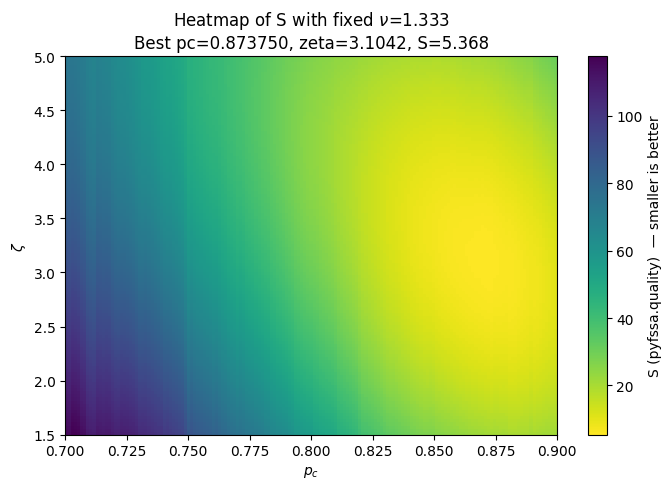

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "TEE_merged.npz"   # あなたの npz
# L はあなたの流儀に合わせて用意（TEE_cols と同数・同順）
# 例: Ah=36,54,72,90,108 → L=sqrt(Ah)
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [2, 3, 4, 5, 6]  # 使う系列（TEE2..TEE6）

# p 窓（あなたのスクリプトに合わせる）
pc_min = 0.75
pc_max = 0.89

# --- ここを "固定ν" にする ---
NU_FIXED = 1.333  # 例: 1.80（必要なら 1.7656 などに変更）

# 探索レンジ（必要に応じて広げる）
PC_RANGE   = (0.7, 0.9)   # pc の探索範囲
ZETA_RANGE = (1.5,  5.0)    # zeta の探索範囲
N_PC, N_ZETA = 161, 121     # グリッド解像度

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と SE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

def key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{key(c)}_var"]     for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{key(c)}_var_err"] for c in TEE_cols], float)

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (pc, zeta) グリッドで S=quality を評価
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)
S_grid = np.empty((N_ZETA, N_PC), float); S_grid[:] = np.nan

best = (np.inf, None, None)

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        # pyfssa のスケール変換（νは固定 → pc と ζ を走査）
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)  # ← pyfssaベースの評価関数
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < best[0]:
            best = (S, pc, zeta)

Smin, pc_best, zeta_best = best
print(f"Best over grid: pc≈{pc_best:.6f}, zeta≈{zeta_best:.4f}, S≈{Smin:.4g} (nu fixed={NU_FIXED})")

# ======================
# 可視化
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto', cmap="viridis_r")
plt.colorbar(im, label="S (pyfssa.quality)  — smaller is better")
plt.xlabel(r"$p_c$"); plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap of S with fixed $\\nu$={NU_FIXED}\nBest pc={pc_best:.6f}, zeta={zeta_best:.4f}, S={Smin:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_pyfssa_fixed_nu1333.png", dpi=300)
plt.show()

# 保存（再利用用）
np.savez("Sgrid_pyfssa_fixednu.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols))


Best over grid: pc≈0.877500, zeta≈3.8333, S≈4.945 (nu fixed=1.7656)


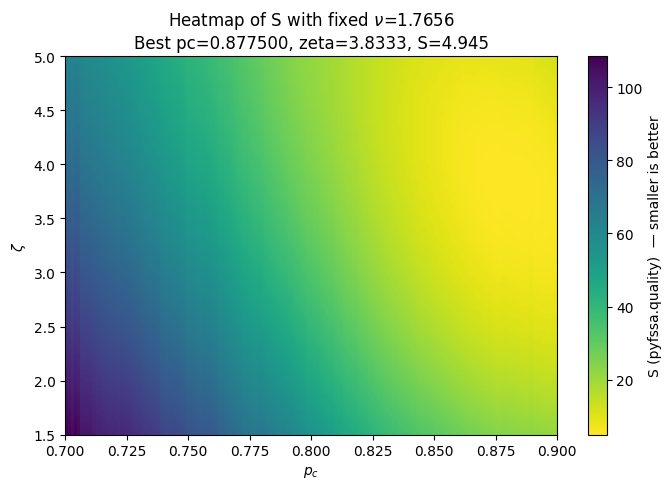

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "fss_merged.npz"   # あなたの npz
# L はあなたの流儀に合わせて用意（TEE_cols と同数・同順）
# 例: Ah=36,54,72,90,108 → L=sqrt(Ah)
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [2, 3, 4, 5, 6]  # 使う系列（TEE2..TEE6）

# p 窓（あなたのスクリプトに合わせる）
pc_min = 0.75
pc_max = 0.89

# --- ここを "固定ν" にする ---
NU_FIXED = 1.7656 # 例: 1.80（必要なら 1.7656 などに変更）

# 探索レンジ（必要に応じて広げる）
PC_RANGE   = (0.7, 0.9)   # pc の探索範囲
ZETA_RANGE = (1.5,  5.0)    # zeta の探索範囲
N_PC, N_ZETA = 161, 121     # グリッド解像度

# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と SE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

def key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{key(c)}_var"]     for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{key(c)}_var_err"] for c in TEE_cols], float)

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (pc, zeta) グリッドで S=quality を評価
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)
S_grid = np.empty((N_ZETA, N_PC), float); S_grid[:] = np.nan

best = (np.inf, None, None)

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        # pyfssa のスケール変換（νは固定 → pc と ζ を走査）
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)  # ← pyfssaベースの評価関数
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < best[0]:
            best = (S, pc, zeta)

Smin, pc_best, zeta_best = best
print(f"Best over grid: pc≈{pc_best:.6f}, zeta≈{zeta_best:.4f}, S≈{Smin:.4g} (nu fixed={NU_FIXED})")

# ======================
# 可視化
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto', cmap="viridis_r")
plt.colorbar(im, label="S (pyfssa.quality)  — smaller is better")
plt.xlabel(r"$p_c$"); plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap of S with fixed $\\nu$={NU_FIXED}\nBest pc={pc_best:.6f}, zeta={zeta_best:.4f}, S={Smin:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_pyfssa_fixed_nu17656.png", dpi=300)
plt.show()

# 保存（再利用用）
np.savez("Sgrid_pyfssa_fixednu.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols))


In [ ]:
平均からの誤差を流用

Using p range: [0.720000, 0.900000]  (N=19)


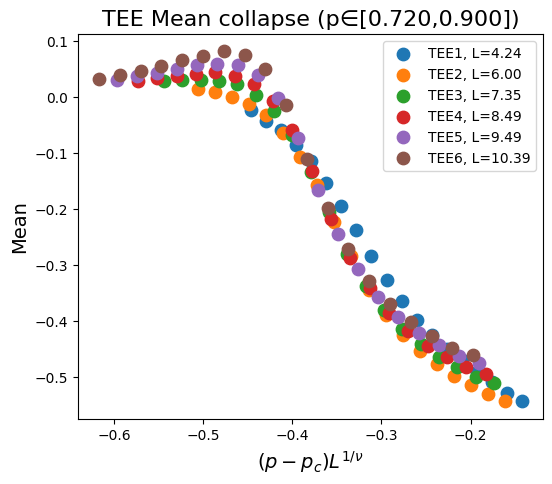

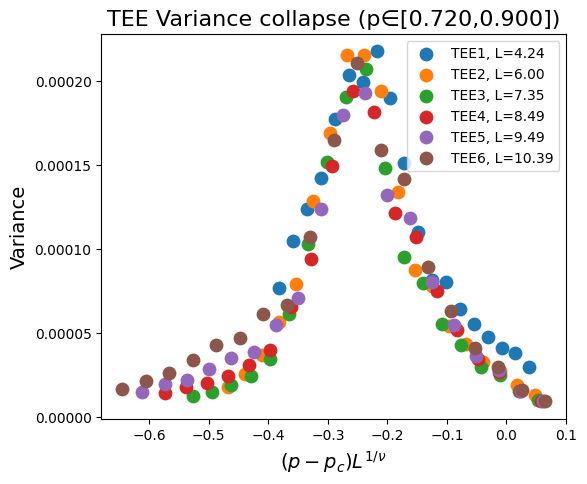

=== 平均 FSS ===
pc = 0.9844040970360879 ± 0.0025535936581012786
nu = 2.7619346253218886 ± 0.03874977302969574
zeta = 0.8227519183989942 ± 0.5025311497851833
S (mean) = 1394.6446256261497

=== 分散 FSS ===
pc = 0.8835461180127383 ± 0.04969894385415566
nu = 1.7062759034647463 ± 0.38260714240090904
zeta = 3.390045265410035 ± 0.6273958239816217
S (var)  = 0.2250437083861608

=== 生の誤差配列（マスク後） ===
da_mean_sel shape: (6, 19) (nL, nP)
da_var_sel  shape: (6, 19) (nL, nP)
[TEE1] da_mean_sel[0, :]: [0.00082654 0.00096216 0.00104574 0.001122   0.0012531  0.00134274 0.00132728 0.0013875  0.001296   0.00115682 0.00098875 0.00084939 0.00084286 0.00075644
 0.00070235 0.00065213 0.00060512 0.0005806  0.00051365]
[TEE2] da_mean_sel[1, :]: [0.00056197 0.00067785 0.00080607 0.00100167 0.0011814  0.00150542 0.0017244  0.00194685 0.00194788 0.0018496  0.00153678 0.00124048 0.00117235 0.00098004
 0.00087674 0.00076101 0.00069737 0.00058146 0.00048443]
[TEE3] da_mean_sel[2, :]: [0.00058346 0.0006258  0.00071237 

In [4]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.72, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.86, nu0=1.82, zeta0=2.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))
# ======================
# 誤差の標準出力（そのまま / 要約）
# ======================
np.set_printoptions(linewidth=160, suppress=True)

print("\n=== 生の誤差配列（マスク後） ===")
print("da_mean_sel shape:", da_mean_sel.shape, "(nL, nP)")
print("da_var_sel  shape:", da_var_sel.shape,  "(nL, nP)")

# Lごとに1行で出力（大きいなら要約だけ使ってください）
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_mean_sel[{i}, :]:", da_mean_sel[i])
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_var_sel [{i}, :]:", da_var_sel[i])

# スケーリング後の y-誤差（collapse座標の誤差）
print("\n=== collapse後の誤差（dys_*） ===")
print("dys_mean shape:", dys_mean.shape, "(nP, nL)")
print("dys_var  shape:", dys_var.shape,  "(nP, nL)")

# 行列を Lごとに1列として出したい場合（必要なら）
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_mean[:, {i}]:", dys_mean[:, i])
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_var [:, {i}]:", dys_var[:, i])

# 見やすい要約統計（最小値/中央値/最大値）
def stats(a):
    return dict(min=float(np.nanmin(a)), median=float(np.nanmedian(a)), max=float(np.nanmax(a)))

print("\n=== 誤差の要約統計 ===")
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_mean_sel stats:", stats(da_mean_sel[i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_var_sel  stats:", stats(da_var_sel[i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_mean     stats:", stats(dys_mean[:, i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_var      stats:", stats(dys_var[:, i]))

# どれだけ残っているかを可視化
print("len(pg) =", len(p_all))
print("count in [pmin,pmax] =", np.count_nonzero((p_all >= pmin) & (p_all <= pmax)))
print("pg in window (head):", p_all[(p_all >= pmin) & (p_all <= pmax)][:10])

# Lごとに NaN/inf がないか（窓内のみで）
mask = (p_all >= pmin) & (p_all <= pmax)
for i, key in enumerate(TEE_keys):
    ok = np.isfinite(a_var[i, mask]) & np.isfinite(da_var[i, mask])
    print(f"{key}: window points =", np.sum(mask),
          " usable =", np.count_nonzero(ok),
          " dropped =", np.sum(~ok))

Best over grid (nu fixed=1.3333): pc≈0.870000, zeta≈3.1625, S≈0.2315


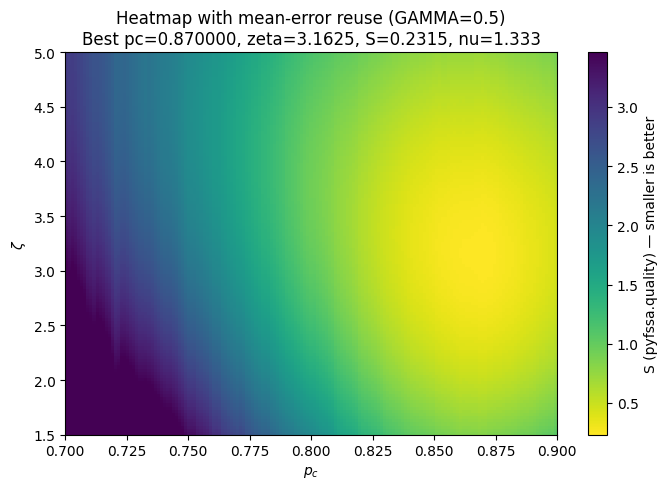

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [2, 3, 4, 5, 6]    # TEE1..TEE6 を使用

# p窓
pc_min, pc_max = 0.72, 0.9

# ---- 固定 ν ----
NU_FIXED = 4/3

# 探索レンジ
PC_RANGE   = (0.7, 0.9)
ZETA_RANGE = (1.5,  5.0)
N_PC, N_ZETA = 161, 121

# 誤差スケール（平均err流用時の任意係数）
GAMMA = 0.5   # (=1で素の流用。0.5にすると重み×4になるので注意)

# 誤差フロア（ゼロ重み/過小見積りの暴走回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と "平均の誤差を流用"）
# ======================
dat = np.load(npz_path)
pg = dat["pg"].astype(float)

def key(c): return f"TEE{c}"
a_var   = np.array([dat[f"{key(c)}_var"] for c in TEE_cols], float)       # shape=(nL,nP)
# ここがポイント：分散の誤差に「平均の誤差」を流用
da_mean = np.array([dat[f"{key(c)}_err"] for c in TEE_cols], float) * GAMMA
da_var  = da_mean.copy()

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
if not np.any(mask):
    raise ValueError("p窓にデータがありません。pc_min/max を見直してください。")

pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並べる ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (p_c, ζ) グリッドで S=quality を評価（νは固定）
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)

S_grid = np.full((N_ZETA, N_PC), np.nan, dtype=float)
bestS, best_pc, best_zeta = np.inf, None, None

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < bestS:
            bestS, best_pc, best_zeta = S, pc, zeta

print(f"Best over grid (nu fixed={NU_FIXED:.4f}): "
      f"pc≈{best_pc:.6f}, zeta≈{best_zeta:.4f}, S≈{bestS:.4g}")

# ======================
# 可視化（外れ値で真っ黒回避のため上限クリップは任意）
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
# 95%パーセンタイルでカラーバー上限クリップ（任意）
finite_S = S_grid[np.isfinite(S_grid)]
vmax = np.percentile(finite_S, 95) if finite_S.size else None
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto',
                cmap="viridis_r", vmin=np.nanmin(S_grid), vmax=vmax)
plt.colorbar(im, label="S (pyfssa.quality) — smaller is better")
plt.xlabel(r"$p_c$")
plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap with mean-error reuse (GAMMA={GAMMA})\n"
          f"Best pc={best_pc:.6f}, zeta={best_zeta:.4f}, S={bestS:.4g}, nu={NU_FIXED:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_meanErrReuse_TEE1-6_fixed_nu_1333.png", dpi=300)
plt.show()

# 保存
np.savez("Sgrid_meanErrReuse_fixednu_nu_1333.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols),
         gamma=GAMMA, err_floor_rel=ERR_FLOOR_REL)


Best over grid (nu fixed=1.7063): pc≈0.885000, zeta≈3.8042, S≈0.2132


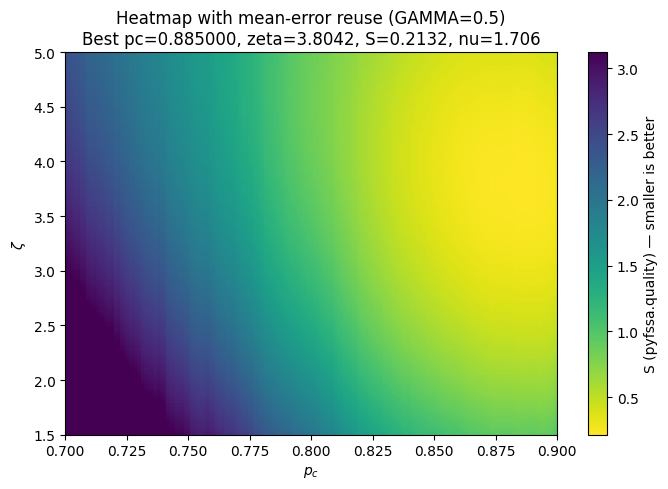

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [2, 3, 4, 5, 6]    # TEE1..TEE6 を使用

# p窓
pc_min, pc_max = 0.72, 0.9

# ---- 固定 ν ----
NU_FIXED = 1.7062759034647463

# 探索レンジ
PC_RANGE   = (0.7, 0.9)
ZETA_RANGE = (1.5,  5.0)
N_PC, N_ZETA = 161, 121

# 誤差スケール（平均err流用時の任意係数）
GAMMA = 0.5   # (=1で素の流用。0.5にすると重み×4になるので注意)

# 誤差フロア（ゼロ重み/過小見積りの暴走回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と "平均の誤差を流用"）
# ======================
dat = np.load(npz_path)
pg = dat["pg"].astype(float)

def key(c): return f"TEE{c}"
a_var   = np.array([dat[f"{key(c)}_var"] for c in TEE_cols], float)       # shape=(nL,nP)
# ここがポイント：分散の誤差に「平均の誤差」を流用
da_mean = np.array([dat[f"{key(c)}_err"] for c in TEE_cols], float) * GAMMA
da_var  = da_mean.copy()

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
if not np.any(mask):
    raise ValueError("p窓にデータがありません。pc_min/max を見直してください。")

pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並べる ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (p_c, ζ) グリッドで S=quality を評価（νは固定）
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)

S_grid = np.full((N_ZETA, N_PC), np.nan, dtype=float)
bestS, best_pc, best_zeta = np.inf, None, None

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < bestS:
            bestS, best_pc, best_zeta = S, pc, zeta

print(f"Best over grid (nu fixed={NU_FIXED:.4f}): "
      f"pc≈{best_pc:.6f}, zeta≈{best_zeta:.4f}, S≈{bestS:.4g}")

# ======================
# 可視化（外れ値で真っ黒回避のため上限クリップは任意）
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
# 95%パーセンタイルでカラーバー上限クリップ（任意）
finite_S = S_grid[np.isfinite(S_grid)]
vmax = np.percentile(finite_S, 95) if finite_S.size else None
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto',
                cmap="viridis_r", vmin=np.nanmin(S_grid), vmax=vmax)
plt.colorbar(im, label="S (pyfssa.quality) — smaller is better")
plt.xlabel(r"$p_c$")
plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap with mean-error reuse (GAMMA={GAMMA})\n"
          f"Best pc={best_pc:.6f}, zeta={best_zeta:.4f}, S={bestS:.4g}, nu={NU_FIXED:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_meanErrReuse_TEE1-6_fixed_nu_1333.png", dpi=300)
plt.show()

# 保存
np.savez("Sgrid_meanErrReuse_fixednu_nu_1333.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols),
         gamma=GAMMA, err_floor_rel=ERR_FLOOR_REL)
